In [16]:
import pandas as pd
import numpy as np
from pyomo.environ import *
from pyomo.dae import *
import matplotlib.pyplot as plt

df = pd.read_excel('dados2.xlsx', sheet_name='Planilha1') 
t_exp = df['x'].values 

# 1. CONFIGURAÇÕES INICIAIS E PROPRIEDADES FÍSICAS
P_total = 47.5  # bar
P_h2 = 0.9524 * P_total  # bar
T_reactor = 375 + 273.15  # K
R_gas = 8.314e-3  # kJ/(mol·K)

lumps_n = ['Hn', 'Dn', 'Qn', 'Nn']
lumps_iso = ['Hiso', 'Diso', 'Qiso', 'Niso']
lumps = lumps_n + lumps_iso + ['G']

# 2. DADOS EXPERIMENTAIS E CONVERSÃO (MOLS -> MASSA)

# Pesos Moleculares (g/mol)
MW = {'Hn': 422.0, 'Hiso': 422.0, 'Dn': 261.0, 'Diso': 261.0, 
      'Qn': 170.0, 'Qiso': 170.0, 'Nn': 100.0, 'Niso': 100.0, 'G': 37.0}

t_exp = df['x'].values

# Pega os dados originais (Molar)
somas_molar = df[lumps].sum(axis=1)
dados_exp_molar = {l: (df[l] / somas_molar).values for l in lumps}

# Converte para Massa para o Pyomo treinar
dados_exp_mass = {l: np.zeros(len(t_exp)) for l in lumps}
for idx in range(len(t_exp)):
    massa_total_ponto = sum(dados_exp_molar[l][idx] * MW[l] for l in lumps)
    for l in lumps:
        dados_exp_mass[l][idx] = (dados_exp_molar[l][idx] * MW[l]) / massa_total_ponto

# O Pyomo usará os dados de MASSA
dados_exp = dados_exp_mass  
val_iniciais = {l: dados_exp_mass[l][0] for l in lumps}

def solve_estimation():
    m = ConcreteModel()
    m.t = ContinuousSet(initialize=t_exp) # Representa o tau (tempo espacial)
    m.lump = Set(initialize=lumps)
    
    mu5 = 1/3
    mu5_star = 13/96
    mu6 = 9/16

    m.E_iso = Param(['H', 'D', 'Q', 'N'], initialize={'H': 206.0, 'D': 194.0, 'Q': 194.0, 'N': 194.0})
    m.E_crack = Param(['Hcr', 'Dcr', 'Qcr', 'Ncr'], initialize={'Hcr': 187.0, 'Dcr': 182.0, 'Qcr': 166.0, 'Ncr': 130.0})

    m.Keq = Param(['Hiso', 'Diso', 'Qiso', 'Niso'], initialize=1000.0)

    # Variáveis a estimar
    m.KL = Var(lumps, initialize=0.05, bounds=(1e-5, 10.0))
    m.KL['G'].fix(1e-5) # Gás não adsorve

    def _init_ln_k0(m, l): return 35.0
    m.ln_k0_iso = Var(['H', 'D', 'Q', 'N'], initialize=_init_ln_k0, bounds=(20.0, 50.0))
    m.ln_k0_crack = Var(['Hcr', 'Dcr', 'Qcr', 'Ncr'], initialize=_init_ln_k0, bounds=(15.0, 50.0))

    # CÁLCULO CINÉTICO (ARRHENIUS)
    def _k_iso_calc(m, l):
        return exp(m.ln_k0_iso[l] - (m.E_iso[l] / (R_gas * T_reactor)))
    m.k_iso = Expression(['H', 'D', 'Q', 'N'], rule=_k_iso_calc)

    def _k_crack_calc(m, l):
        return exp(m.ln_k0_crack[l] - (m.E_crack[l] / (R_gas * T_reactor)))
    m.k_crack = Expression(['Hcr', 'Dcr', 'Qcr', 'Ncr'], rule=_k_crack_calc)

    # VARIÁVEIS DE ESTADO: Fração Mássica (Y)
    m.Y = Var(m.lump, m.t, within=NonNegativeReals, bounds=(1e-9, 1.0), initialize=0.1)
    m.dYdt = DerivativeVar(m.Y, wrt=m.t)
    
    # 1. Transformação de Y (Massa) para y (Mols) para achar Pressão Parcial
    def _sum_mols(m, t):
        return sum(m.Y[l, t] / MW[l] for l in lumps)
        
    def _p(m, lump, t):
        y_molar = (m.Y[lump, t] / MW[lump]) / _sum_mols(m, t)
        return y_molar * P_total
    
    def _adsorb(m, t):
        soma_KLp = sum(m.KL[lump] * _p(m, lump, t) for lump in lumps if lump != 'G')
        return P_h2 * (1 + soma_KLp)

    # EQUAÇÕES DIFERENCIAIS
    def _balanco(m, l, t):
        A = _adsorb(m, t)
        
        # --- Taxas de Reação Molares (r) em kmol/(kg_cat * h) ---
        r_iso_H = (m.k_iso['H'] / A) * (_p(m, 'Hn', t) - _p(m, 'Hiso', t) / m.Keq['Hiso'])
        r_iso_D = (m.k_iso['D'] / A) * (_p(m, 'Dn', t) - _p(m, 'Diso', t) / m.Keq['Diso'])
        r_iso_Q = (m.k_iso['Q'] / A) * (_p(m, 'Qn', t) - _p(m, 'Qiso', t) / m.Keq['Qiso'])
        r_iso_N = (m.k_iso['N'] / A) * (_p(m, 'Nn', t) - _p(m, 'Niso', t) / m.Keq['Niso'])
        
        r_cr_H = (m.k_crack['Hcr'] / A) * _p(m, 'Hiso', t)
        r_cr_D = (m.k_crack['Dcr'] / A) * _p(m, 'Diso', t)
        r_cr_Q = (m.k_crack['Qcr'] / A) * _p(m, 'Qiso', t)
        r_cr_N = (m.k_crack['Ncr'] / A) * _p(m, 'Niso', t)

        # --- Balanços de Massa: Derivada = Taxa Molar * Peso Molecular ---
        if l == 'Hn':
            return m.dYdt[l, t] == (-r_iso_H) * MW[l]
        elif l == 'Dn':
            return m.dYdt[l, t] == (-r_iso_D) * MW[l]
        elif l == 'Qn':
            return m.dYdt[l, t] == (-r_iso_Q) * MW[l]
        elif l == 'Nn':
            return m.dYdt[l, t] == (-r_iso_N) * MW[l]
            
        elif l == 'Hiso':
            return m.dYdt[l, t] == (r_iso_H - r_cr_H) * MW[l]
            
        elif l == 'Diso':
            from_H = 2 * mu5 * r_cr_H
            return m.dYdt[l, t] == (r_iso_D + from_H - r_cr_D) * MW[l]
            
        elif l == 'Qiso':
            from_H = 2 * mu5_star * r_cr_H
            from_D = 2 * (1 - mu6) * r_cr_D
            return m.dYdt[l, t] == (r_iso_Q + from_H + from_D - r_cr_Q) * MW[l]
            
        elif l == 'Niso':
            from_D = 2 * mu6 * r_cr_D
            from_Q = 2 * r_cr_Q
            return m.dYdt[l, t] == (r_iso_N + from_D + from_Q - r_cr_N) * MW[l]
            
        elif l == 'G':
            from_N = 2 * r_cr_N
            return m.dYdt[l, t] == (from_N) * MW[l]
            
    m.ode = Constraint(m.lump, m.t, rule=_balanco)
    
    # Restrições Físicas (Hierarquia de Craqueamento e Adsorção)
    m.c_reaktiv1 = Constraint(expr= m.k_crack['Hcr'] >= m.k_crack['Dcr'])
    m.c_reaktiv2 = Constraint(expr= m.k_crack['Dcr'] >= m.k_crack['Qcr'])
    m.c_reaktiv3 = Constraint(expr= m.k_crack['Qcr'] >= m.k_crack['Ncr'])
    
    m.c_kl_iso1 = Constraint(expr= m.KL['Hn'] == m.KL['Hiso'])
    m.c_kl_iso2 = Constraint(expr= m.KL['Dn'] == m.KL['Diso'])
    m.c_kl_iso3 = Constraint(expr= m.KL['Qn'] == m.KL['Qiso'])
    m.c_kl_iso4 = Constraint(expr= m.KL['Nn'] == m.KL['Niso'])
    
    m.c_kl_hier1 = Constraint(expr= m.KL['Hn'] >= m.KL['Dn'])
    m.c_kl_hier2 = Constraint(expr= m.KL['Dn'] >= m.KL['Qn'])
    m.c_kl_hier3 = Constraint(expr= m.KL['Qn'] >= m.KL['Nn'])

    t_inicial = m.t.first()
    
    # 1. Primeiro, fixa TODOS os lumps nos valores experimentais do tempo 0.
    # Isso garante que a carga (Hn, Dn, Qn, Nn) comece nos pontos corretos.
    for l in lumps:
        m.Y[l, t_inicial].fix(val_iniciais[l])
        
    # 2. Agora, garante o ZERO ESTRITO APENAS para os produtos reais.
    # Olhando seus gráficos, apenas as isoparafinas e o Gás começam do zero.
    lumps_produtos = ['Hiso', 'Diso', 'Qiso', 'Niso', 'G']
    for l in lumps_produtos:
        m.Y[l, t_inicial].fix(1e-9)

    def _obj(m):
        obj_val = 0
        for l in lumps:
            weight = 1.0 / (np.max(dados_exp[l]) + 1e-3) 
            for idx, t_val in enumerate(t_exp):
                # Compara as frações MÁSSICAS
                diff = (m.Y[l, t_val] - dados_exp[l][idx])
                obj_val += weight * (diff**2)
        return obj_val
    
    m.obj = Objective(rule=_obj, sense=minimize)
    
    TransformationFactory('dae.collocation').apply_to(m, nfe=40, ncp=4) 
    solver = SolverFactory('ipopt', executable=r'c:\zebra\ipopt.exe')
    solver.options['max_iter'] = 3000
    solver.options['tol'] = 1e-6
    
    results = solver.solve(m, tee=True)
    return m

try:
    model = solve_estimation()
    if model is not None:
        print("\n" + "="*80)
        print("RESULTADOS")
        print("="*80)
        
        for l in ['H', 'D', 'Q', 'N']:
            print(f"k0_iso_{l} = {np.exp(value(model.ln_k0_iso[l])):.3e}")
        print("-" * 40)
        for l in ['Hcr', 'Dcr', 'Qcr', 'Ncr']:
            print(f"k0_cr_{l}  = {np.exp(value(model.ln_k0_crack[l])):.3e}")
        print("-" * 40)
        for l in lumps:
            print(f"KL_{l} = {value(model.KL[l]):.4e}")

except Exception as e:
    print(e)

WARNING (W1002): Setting Var 'Y[Hiso,0.0]' to a numeric value `0.0` outside
the bounds (1e-09, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'Y[Diso,0.0]' to a numeric value `0.0` outside
the bounds (1e-09, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'Y[Qiso,0.0]' to a numeric value `0.0` outside
the bounds (1e-09, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'Y[Niso,0.0]' to a numeric value `0.0` outside
the bounds (1e-09, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
WARNING (W1002): Setting Var 'Y[G,0.0]' to a numeric value `0.0` outside the
bounds (1e-09, 1.0).
    See also https://pyomo.readthedocs.io/en/stable/errors.html#w1002
Ipopt 3.12.13: max_iter=3000
tol=1e-06


******************************************************************************
This program contains Ipopt,

C:\Users\giovani25025\AppData\Local\Temp\ipykernel_17612\2243379797.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


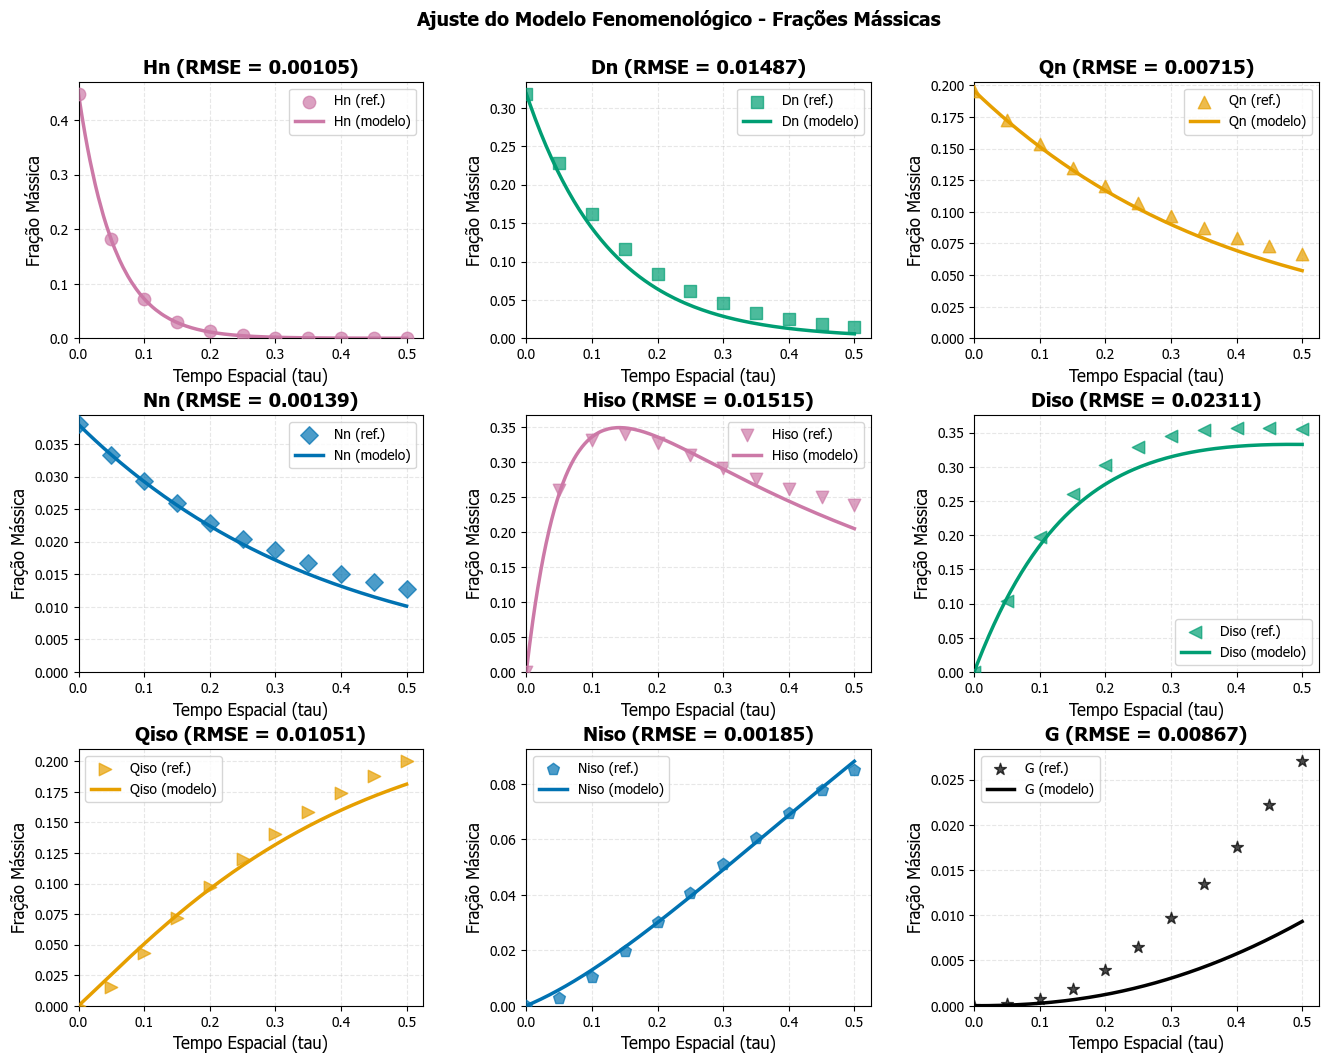

In [17]:
# 5. GRÁFICOS DETALHADOS DE CADA COMPONENTE (Frações Mássicas)

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

if 'model' in locals() and model is not None:
    
    t_plot = sorted(list(model.t))
    t_plot_array = np.array(t_plot)
    
    fig = plt.figure(figsize=(16, 12))
    gs = GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)
    
    # Paleta acessível (Okabe-Ito adaptada para seus grupos)
    cores = {
        'Nn': '#0072B2', 'Niso': '#0072B2',   # Azul escuro
        'Qn': '#E69F00', 'Qiso': '#E69F00',   # Laranja
        'Dn': '#009E73', 'Diso': '#009E73',   # Verde-azulado (seguro)
        'Hn': '#CC79A7', 'Hiso': '#CC79A7',   # Púrpura-avermelhado (seguro)
        'G': '#000000'                        # Preto
    }
    marcadores = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*']
    rmse_values = {}
    
    # Extrai o modelo contínuo DIRETAMENTE em Fração Mássica
    y_cont_mass = {l: [] for l in lumps}
    for t_val in t_plot:
        for l in lumps:
            y_cont_mass[l].append(value(model.Y[l, t_val]))

    y_cont_mass['G'][0] = 0.0
    
    for idx, lump in enumerate(lumps):
        row, col = idx // 3, idx % 3
        ax = fig.add_subplot(gs[row, col])
        
        # Plota os dados experimentais MÁSSICOS
        ax.scatter(t_exp, dados_exp_mass[lump], 
                  color=cores.get(lump, 'gray'), marker=marcadores[idx % len(marcadores)],
                  s=80, alpha=0.7, label=f'{lump} (ref.)', zorder=3)
        
        # Plota a curva contínua do modelo MÁSSICA
        ax.plot(t_plot, y_cont_mass[lump], 
               color=cores.get(lump, 'gray'), linewidth=2.5, 
               label=f'{lump} (modelo)', zorder=2)
        
        # Calcula RMSE na base Mássica
        y_model_pts = []
        for t_val in t_exp:
            idx_t = np.argmin(np.abs(t_plot_array - t_val))
            y_model_pts.append(y_cont_mass[lump][idx_t])
            
        rmse = np.sqrt(np.mean((np.array(dados_exp_mass[lump]) - np.array(y_model_pts))**2))
        rmse_values[lump] = rmse
        
        ax.set_xlabel('Tempo Espacial (tau)', fontsize=12)
        ax.set_ylabel('Fração Mássica', fontsize=12)
        ax.set_title(f'{lump} (RMSE = {rmse:.5f})', fontweight='bold', fontsize=14)
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='best', fontsize=10)
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)
    
    plt.suptitle('Ajuste do Modelo Fenomenológico - Frações Mássicas', 
                 fontsize=14, fontweight='bold', y=0.94)
    plt.tight_layout()
    # Salva a figura com o nome atualizado
    plt.savefig('grafico_fracoes_massicas_g_fixo', dpi=1200, bbox_inches='tight')
    plt.show()

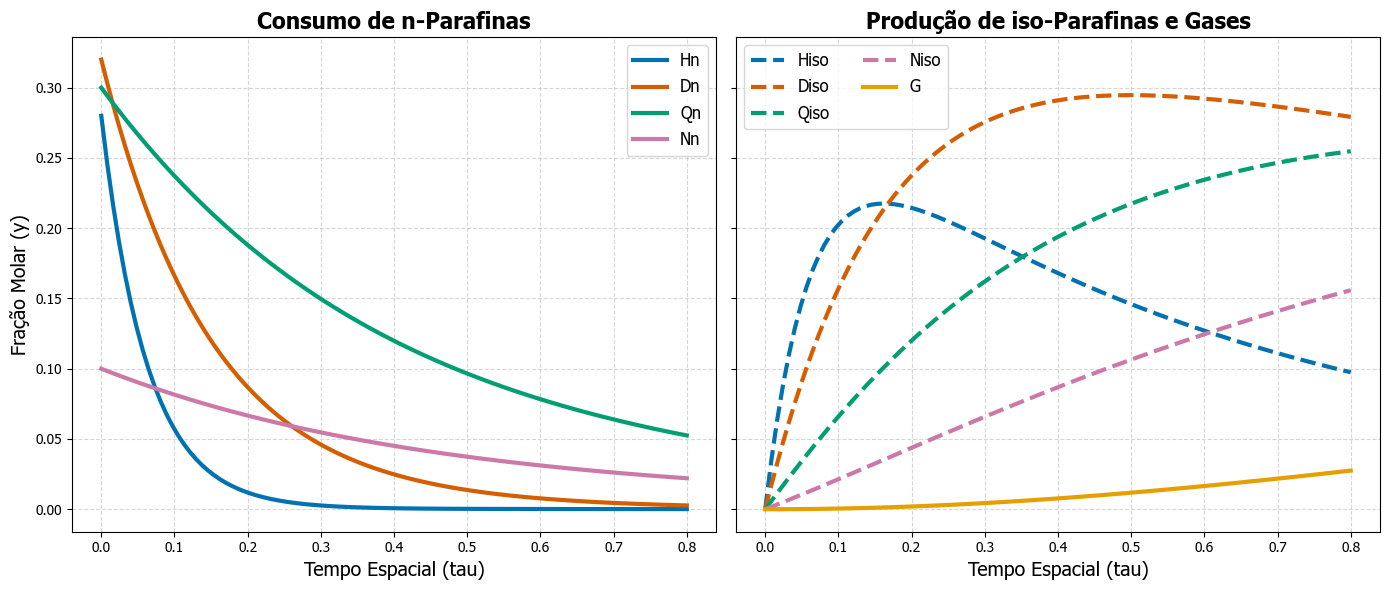

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. PARÂMETROS OTIMIZADOS
T_reactor = 375 + 273.15 
P_total = 47.5 
P_h2 = 0.9524 * P_total
R_gas = 8.314e-3

# Coloque aqui os valores exatos que saíram no seu terminal IPOPT:
k0_iso = {'H': 2.858e+15, 'D': 1.267e+14, 'Q': 4.533e+13, 'N': 3.936e+13}
k0_cr  = {'Hcr': 8.201e+12, 'Dcr': 1.288e+12, 'Qcr': 6.613e+10, 'Ncr': 8.300e+07}
E_iso = {'H': 206.0, 'D': 194.0, 'Q': 194.0, 'N': 194.0}
E_cr  = {'Hcr': 187.0, 'Dcr': 182.0, 'Qcr': 166.0, 'Ncr': 130.0}
KL    = 1.58e-04 # Usando o valor do Squalane (H) como referência de base

lumps = ['Hn', 'Dn', 'Qn', 'Nn', 'Hiso', 'Diso', 'Qiso', 'Niso', 'G']
MW = {'Hn': 422.0, 'Hiso': 422.0, 'Dn': 261.0, 'Diso': 261.0, 
      'Qn': 170.0, 'Qiso': 170.0, 'Nn': 100.0, 'Niso': 100.0, 'G': 37.0}

def reator_pfr_mass(Y, tau):
    # Y = Fração Mássica
    Y_dict = {lumps[i]: max(Y[i], 1e-9) for i in range(len(lumps))}
    
    # Massa -> Mol
    mols_total = sum(Y_dict[l] / MW[l] for l in lumps)
    y_molar = {l: (Y_dict[l] / MW[l]) / mols_total for l in lumps}
    p = {l: y_molar[l] * P_total for l in lumps}
    
    # Arrhenius
    k_i = {l: k0_iso[l] * np.exp(-E_iso[l]/(R_gas*T_reactor)) for l in ['H','D','Q','N']}
    k_c = {l: k0_cr[l] * np.exp(-E_cr[l]/(R_gas*T_reactor)) for l in ['Hcr','Dcr','Qcr','Ncr']}
    
    A = P_h2 * (1 + KL * sum(p[l] for l in lumps if l != 'G'))
    
    # Taxas molares auxiliares (para facilitar a leitura)
    r_iso_H = (k_i['H']/A)*(p['Hn'] - p['Hiso']/1000)
    r_iso_D = (k_i['D']/A)*(p['Dn'] - p['Diso']/1000)
    r_iso_Q = (k_i['Q']/A)*(p['Qn'] - p['Qiso']/1000)
    r_iso_N = (k_i['N']/A)*(p['Nn'] - p['Niso']/1000)
    
    r_cr_H = (k_c['Hcr']/A)*p['Hiso']
    r_cr_D = (k_c['Dcr']/A)*p['Diso']
    r_cr_Q = (k_c['Qcr']/A)*p['Qiso']
    r_cr_N = (k_c['Ncr']/A)*p['Niso']

    dYdtau = np.zeros(len(lumps))
    
    # n-parafinas (Consumidas pela isomerização)
    dYdtau[0] = -r_iso_H * MW['Hn']
    dYdtau[1] = -r_iso_D * MW['Dn']
    dYdtau[2] = -r_iso_Q * MW['Qn']
    dYdtau[3] = -r_iso_N * MW['Nn']
    
    # iso-parafinas (Ganham pela isomerização, perdem pelo craqueamento)
    # Craqueamento gera 2 mols de fragmentos, por isso o fator 2
    dYdtau[4] = (r_iso_H - r_cr_H) * MW['Hiso']
    dYdtau[5] = (r_iso_D + (2/3)*r_cr_H - r_cr_D) * MW['Diso']
    dYdtau[6] = (r_iso_Q + (13/48)*r_cr_H + 0.875*r_cr_D - r_cr_Q) * MW['Qiso']
    dYdtau[7] = (r_iso_N + (9/16)*r_cr_D + 2*r_cr_Q - r_cr_N) * MW['Niso']
    
    # Gases (Ganham massa do craqueamento de Niso)
    dYdtau[8] = 2 * r_cr_N * MW['G']
    return dYdtau

# 5. EXECUÇÃO E PLOT
tau = np.linspace(0, 0.8, 100)
# Vetor condição inicial em fração MOLAR
Y0 = [0.28, 0.32, 0.30, 0.10, 0.0, 0.0, 0.0, 0.0, 0.0]
sol = odeint(reator_pfr_mass, Y0, tau)

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahoma']

# 4. GRÁFICOS LADO A LADO PARA O RELATÓRIO
# Paleta Okabe-Ito Acessível para Daltônicos
cores = {'Hn': '#0072B2',   'Dn': '#D55E00',   'Qn': '#009E73',   'Nn': '#CC79A7',
         'Hiso': '#0072B2', 'Diso': '#D55E00', 'Qiso': '#009E73', 'Niso': '#CC79A7', 
         'G': '#E69F00'}

# Criando 1 figura com 2 gráficos (axes[0] na esquerda e axes[1] na direita)
# figsize=(14, 6) garante que a imagem fique larga o suficiente para caber bem na página
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# --- GRÁFICO 1: Consumo de n-Parafinas (Esquerda) ---
n_lumps = ['Hn', 'Dn', 'Qn', 'Nn']
for l in n_lumps:
    idx = lumps.index(l)
    axes[0].plot(tau, sol[:, idx], label=l, color=cores[l], linewidth=3.0)

axes[0].set_title('Consumo de n-Parafinas', fontweight='bold', fontsize=16)
axes[0].set_xlabel('Tempo Espacial (tau)', fontsize=14)
axes[0].set_ylabel('Fração Molar (y)', fontsize=14)
axes[0].legend(fontsize=12, loc='upper right')
axes[0].grid(True, linestyle='--', alpha=0.5)


# --- GRÁFICO 2: Produção de iso-Parafinas e Gases (Direita) ---
iso_and_gas = ['Hiso', 'Diso', 'Qiso', 'Niso', 'G']
for l in iso_and_gas:
    idx = lumps.index(l)
    estilo = '--' if l != 'G' else '-'
    axes[1].plot(tau, sol[:, idx], label=l, color=cores[l], linestyle=estilo, linewidth=3.0)

axes[1].set_title('Produção de iso-Parafinas e Gases', fontweight='bold', fontsize=16)
axes[1].set_xlabel('Tempo Espacial (tau)', fontsize=14)
# O eixo Y foi compartilhado no topo (sharey=True), então não precisamos repetir o label do Y aqui
axes[1].legend(fontsize=12, loc='best', ncol=2) # ncol=2 divide a legenda em 2 colunas para economizar espaço
axes[1].grid(True, linestyle='--', alpha=0.5)


# --- AJUSTE FINAL E SALVAMENTO ---
plt.tight_layout()
plt.savefig('graficos_simulacao_lado_a_lado.png', dpi=1200, bbox_inches='tight')
plt.show()

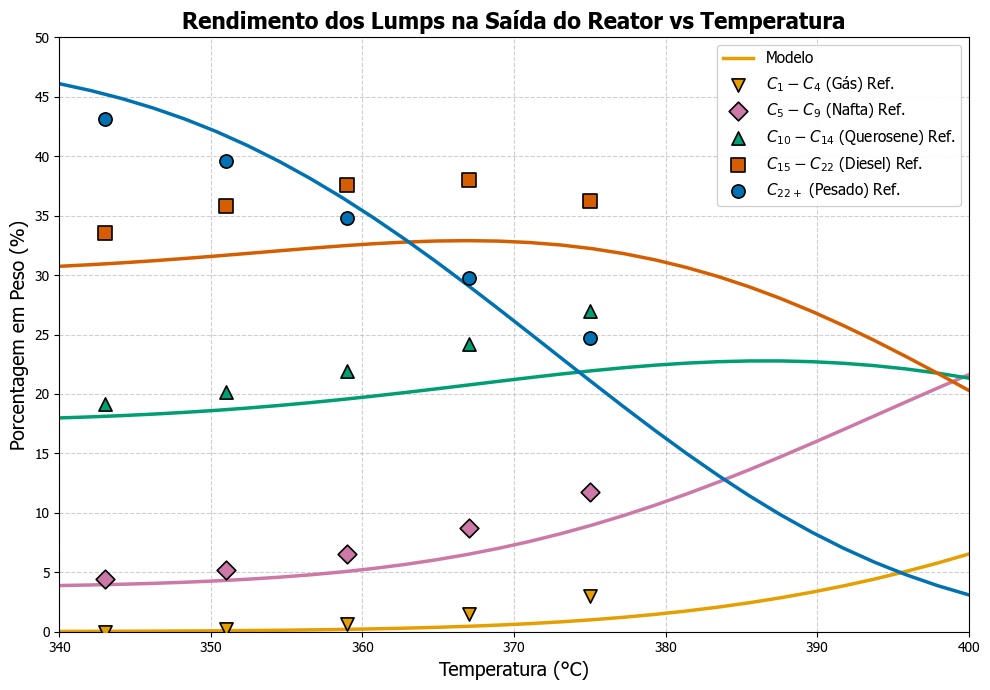

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. PARÂMETROS OTIMIZADOS E FÍSICOS
P_total = 47.5 
P_h2 = 0.9524 * P_total
R_gas = 8.314e-3
KL = 1.58e-04  # Parâmetro ótimo do Pyomo

k0_iso = {'H': 2.858e+15, 'D': 1.267e+14, 'Q': 4.533e+13, 'N': 3.936e+13}
k0_cr  = {'Hcr': 8.201e+12, 'Dcr': 1.288e+12, 'Qcr': 6.613e+10, 'Ncr': 8.300e+07}
E_iso = {'H': 206.0, 'D': 194.0, 'Q': 194.0, 'N': 194.0}
E_cr  = {'Hcr': 187.0, 'Dcr': 182.0, 'Qcr': 166.0, 'Ncr': 130.0}

lumps = ['Hn', 'Dn', 'Qn', 'Nn', 'Hiso', 'Diso', 'Qiso', 'Niso', 'G']
MW = {'Hn': 422.0, 'Hiso': 422.0, 'Dn': 261.0, 'Diso': 261.0, 
      'Qn': 170.0, 'Qiso': 170.0, 'Nn': 100.0, 'Niso': 100.0, 'G': 37.0}

# 2. MODELO DO REATOR (Equações Diferenciais)
def reator_pfr_mass(Y, tau, T_K):
    Y_dict = {lumps[i]: max(Y[i], 1e-12) for i in range(len(lumps))}
    
    # Conversão Massa -> Mol
    mols_total = sum(Y_dict[l] / MW[l] for l in lumps)
    y_molar = {l: (Y_dict[l] / MW[l]) / mols_total for l in lumps}
    p = {l: y_molar[l] * P_total for l in lumps}
    
    # Arrhenius
    k_i = {l: k0_iso[l] * np.exp(-E_iso[l]/(R_gas*T_K)) for l in ['H','D','Q','N']}
    k_c = {l: k0_cr[l] * np.exp(-E_cr[l]/(R_gas*T_K)) for l in ['Hcr','Dcr','Qcr','Ncr']}
    
    A = P_h2 * (1 + KL * sum(p[l] for l in lumps if l != 'G'))
    
    # Taxas Molares
    r_iso_H = (k_i['H']/A)*(p['Hn'] - p['Hiso']/1000)
    r_iso_D = (k_i['D']/A)*(p['Dn'] - p['Diso']/1000)
    r_iso_Q = (k_i['Q']/A)*(p['Qn'] - p['Qiso']/1000)
    r_iso_N = (k_i['N']/A)*(p['Nn'] - p['Niso']/1000)
    
    r_cr_H = (k_c['Hcr']/A)*p['Hiso']
    r_cr_D = (k_c['Dcr']/A)*p['Diso']
    r_cr_Q = (k_c['Qcr']/A)*p['Qiso']
    r_cr_N = (k_c['Ncr']/A)*p['Niso']
    
    # Balanços de Massa (dY/dtau)
    dYdtau = np.zeros(len(lumps))
    dYdtau[0] = -r_iso_H * MW['Hn']
    dYdtau[1] = -r_iso_D * MW['Dn']
    dYdtau[2] = -r_iso_Q * MW['Qn']
    dYdtau[3] = -r_iso_N * MW['Nn']
    
    dYdtau[4] = (r_iso_H - r_cr_H) * MW['Hiso']
    dYdtau[5] = (r_iso_D + (2/3)*r_cr_H - r_cr_D) * MW['Diso']
    dYdtau[6] = (r_iso_Q + (13/48)*r_cr_H + 0.875*r_cr_D - r_cr_Q) * MW['Qiso']
    dYdtau[7] = (r_iso_N + (9/16)*r_cr_D + 2*r_cr_Q - r_cr_N) * MW['Niso']
    dYdtau[8] = 2 * r_cr_N * MW['G']
    
    return dYdtau

# 3. GERAÇÃO DOS DADOS DA FIGURA 8 (Varredura de Temperatura)
# Definindo a faixa de temperaturas (Ex: 340°C a 400°C)
temperaturas_C = np.linspace(340, 400, 30) 
tau_final = 0.5 
tau_span = np.linspace(0, tau_final, 50) # Malha de integração

# Condição de entrada do reator (EM FRAÇAO MASSICA)
Y0 = [0.486, 0.301, 0.176, 0.037, 0.0, 0.0, 0.0, 0.0, 0.0]

# Listas para armazenar a composição de SAÍDA do reator
Y_H_out, Y_D_out, Y_Q_out, Y_N_out, Y_G_out = [], [], [], [], []

for T_C in temperaturas_C:
    T_K = T_C + 273.15
    sol = odeint(reator_pfr_mass, Y0, tau_span, args=(T_K,))
    
    # Captura a última linha da matriz (o fluido na saída do reator)
    Y_final = sol[-1, :]
    
    # SOMA n-parafinas + iso-parafinas para formar o Lump Global (* 100 para % em peso)
    Y_H_out.append((Y_final[0] + Y_final[4]) * 100)  # Hn + Hiso
    Y_D_out.append((Y_final[1] + Y_final[5]) * 100)  # Dn + Diso
    Y_Q_out.append((Y_final[2] + Y_final[6]) * 100)  # Qn + Qiso
    Y_N_out.append((Y_final[3] + Y_final[7]) * 100)  # Nn + Niso
    Y_G_out.append((Y_final[8]) * 100)               # G

# 4. PLOTAGEM ESTILO ARTIGO CIENTÍFICO (FIGURA 8)
# 4. PLOTAGEM ESTILO ARTIGO CIENTÍFICO (FIGURA 8)
plt.figure(figsize=(10, 7))

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahoma']

# =============================================================================
# 4.1 LINHAS DO MODELO CONTÍNUAS (Previsão do seu código)
# Removi os marcadores ('v-', 'D-') deixando apenas '-' para não poluir o gráfico
# =============================================================================
plt.plot(temperaturas_C, Y_G_out, '-', color='#E69F00', linewidth=2.5, zorder=2, label='Modelo') 
plt.plot(temperaturas_C, Y_N_out, '-', color='#CC79A7', linewidth=2.5, zorder=2) 
plt.plot(temperaturas_C, Y_Q_out, '-', color='#009E73', linewidth=2.5, zorder=2) 
plt.plot(temperaturas_C, Y_D_out, '-', color='#D55E00', linewidth=2.5, zorder=2) 
plt.plot(temperaturas_C, Y_H_out, '-', color='#0072B2', linewidth=2.5, zorder=2) 

# =============================================================================
# 4.2 DADOS EXPERIMENTAIS DO ARTIGO (Os pontos do seu CSV)
# =============================================================================
# Dicionários de formatação
cores = {'G': '#E69F00', 'N': '#CC79A7', 'Q': '#009E73', 'D': '#D55E00', 'H': '#0072B2'}
marcadores = {'G': 'v', 'N': 'D', 'Q': '^', 'D': 's', 'H': 'o'}
labels = {'G': '$C_1-C_4$ (Gás)', 'N': '$C_5-C_9$ (Nafta)', 'Q': '$C_{10}-C_{14}$ (Querosene)', 
          'D': '$C_{15}-C_{22}$ (Diesel)', 'H': '$C_{22+}$ (Pesado)'}


df_artigo = pd.read_excel('fig8_pellegrini.xlsx', sheet_name='fig8_pellegrini')
    

colunas_x = 'T'
colunas_y = {'G': 'G', 'N': 'N', 'Q': 'Q', 'D': 'D', 'H': 'H'}
    
for l in ['G', 'N', 'Q', 'D', 'H']:
    plt.scatter(df_artigo[colunas_x], df_artigo[colunas_y[l]], 
                color=cores[l], marker=marcadores[l], s=90, 
                edgecolor='black', linewidth=1.2, zorder=5, 
                label=f'{labels[l]} Ref.')

# =============================================================================
# 4.3 AJUSTE VISUAL DOS EIXOS E LEGENDA
# =============================================================================
plt.title('Rendimento dos Lumps na Saída do Reator vs Temperatura', fontweight='bold', fontsize=16)
plt.xlabel('Temperatura (°C)', fontsize=14)
plt.ylabel('Porcentagem em Peso (%)', fontsize=14)

# Legenda personalizada (Mostra os marcadores com as cores e uma linha guia para o modelo)
handles, legend_labels = plt.gca().get_legend_handles_labels()
# Filtramos para não repetir a legenda "Modelo" 5 vezes, mostrando apenas 1 vez
by_label = dict(zip(legend_labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='best', fontsize=11, framealpha=0.9)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(340, 400)
plt.ylim(0, 50)
plt.yticks(np.arange(0, 55, 5)) 

plt.savefig('rendimento_vs_temperatura.png', dpi=1200, bbox_inches='tight')
plt.tight_layout()
plt.show()